# MNIST SLP

In [ ]:
import os
import numpy as np
import pandas as pd
from plt_rcs import *
import torch

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

In [ ]:
os.getcwd()

In [ ]:
os.chdir('../../data')

In [ ]:
[i for i in os.listdir() if 'MNIST' in i][1]

In [ ]:
objs = pd.read_pickle('MNIST_Dataset.pkl')

In [ ]:
globals().update(objs)

In [ ]:
%whos

In [ ]:
test_mnist, train_mnist = test_mnist, train_mnist

## 이미지 텐서 결합

In [ ]:
img1 = train_mnist[0][0]
img2 = train_mnist[1][0]
print(img1.shape)
print(img2.shape)
# torch.Size([1, 28, 28])
# torch.Size([1, 28, 28])

In [ ]:
stacked_images = torch.stack(tensors=[img1, img2], dim=0)

In [ ]:
stacked_images.shape
# torch.Size([2, 1, 28, 28])

## 이미지 평탄화

In [ ]:
flattened_image = img1.flatten()
flattened_image.shape
# torch.Size([784])

## 훈련셋을 이미지와 라벨로 분리 

In [ ]:
train_images = torch.stack(tensors=[img for img, _ in train_mnist], dim=0)
train_labels = torch.tensor(data=[label for _, label in train_mnist])

In [ ]:
train_images.shape
# torch.Size([60000, 1, 28, 28])
train_labels.shape
# torch.Size([60000])

In [ ]:
# 평탄화 후 재할당
train_images = train_images.reshape(train_images.shape[0], -1)
train_images.shape
# torch.Size([60000, 784])

## 시험셋을 이미지와 라벨로 분리

In [ ]:
test_images = torch.stack(tensors=[img for img, _ in test_mnist])
test_labels = torch.tensor(data=[label for _, label in test_mnist])

In [ ]:
# 평탄화 후 재할당
test_images = test_images.reshape(test_images.shape[0], -1)
test_images.shape
# torch.Size([10000, 784])

## 시드 고정

In [ ]:
# CPU 연산에서의 시드 고정
import random

def set_seed(seed=0):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

In [ ]:
# GPU 연산에서의 시드 고정
import random

def set_seed_gpu(seed=0, deterministic=False):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    if deterministic:
        torch.backends.cudnn.deterministic=True
        torch.backends.cudnn.benchmark=False
        torch.use_deterministic_algorithms(True)

## 단층 퍼셉트론 모델 생성

In [ ]:
import torch.nn as nn

In [ ]:
model = nn.Linear(in_features=784, out_features=10).to(device)

In [ ]:
model
# Linear(in_features=784, out_features=10, bias=True)

In [ ]:
model.weight.shape
# torch.Size([10, 784])

## 손실 함수와 최적화 알고리즘 생성

In [ ]:
# 크로스 엔트로피 손실 함수 생성
criterion = nn.CrossEntropyLoss()

In [ ]:
# 최적화 알고리즘 생성
optimizer = torch.optim.Adam(params=model.parameters(), lr=0.001)

## 단층 퍼셉트론 모델 1회 학습

In [ ]:
# 모델을 학습 모드로 전환
model.train()

In [ ]:
# 각 클래스에 대한 예측 점수(로짓) 계산 -> 순전파
logits = model(train_images)

In [ ]:
# 크로스 엔트로피 손실값 계산
loss = criterion(logits, train_labels)

In [ ]:
# 이전 계산된 기울기를 0으로 초기화
optimizer.zero_grad()

In [ ]:
# 손실 함수를 가중치로 미분하여 기울기 계산 -> 역전파
loss.backward()

In [ ]:
# 기울기를 이용하여 가중치 업데이트 -> 경사하강법
optimizer.step()

## 모델 정확도 확인

In [ ]:
model.eval()
with torch.no_grad():
    logits = model(test_images)
    y_prob = torch.softmax(input=logits, dim=1)
    y_pred = y_prob.argmax(dim=1)
    acc = (test_labels == y_pred).float().mean().item()
print(acc)

## 모델 정확도 평가 함수 생성

In [ ]:
@torch.no_grad()
def accuracy(model, x, y):
    model.eval()
    logits = model(x)
    y_prob = torch.softmax(input=logits, dim=1)
    y_pred = y_prob.argmax(dim=1)
    acc = (y == y_pred).float().mean().item()
    return acc

## 모델 학습 함수 생성

In [ ]:
def train(model, x, y):
    logits = model(x)
    loss = criterion(logits, y)
    optimizer.zero_grad()
    loss.backwar()
    optimizer.step()
    return loss.item()

## 단층 퍼셉트론 모델 반복 학습

In [ ]:
train_losses = []
train_accs = []
test_accs = []

for epoch in range(20):
    model.train()
    loss = train(model, train_images, train_labels)
    train_losses.append(loss)

    train_acc = accuracy(model, train_images, train_labels)
    test_acc = accuracy(model, test_images, test_labels)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    print(f'[Epoch : {epoch + 1:02d}] Loss : {loss:.4f} ',
            f'Train_Acc = {train_acc:.4f}, Test_ACC = {test_acc:.4f}')

- 신경망 모델과 최적화 객체는 새로운 모델을 학습할 때마다 새로 생성해야됨

In [ ]:
model.eval()

In [ ]:
logits = model(test_images[0])
logits

In [ ]:
y_prob = torch.softmax(input=logits.unsqueeze(dim=0), dim=1)
y_prob

In [ ]:
y_prob.sum()

In [ ]:
y_pred = y_prob.argmax(dim=1)
y_pred

## 학습 곡선 시각화

In [ ]:
# 손실값
plt.plot(train_losses, label='훈련셋 손실값')
plt.title('훈련셋 손실값 변화')
plt.xlabel('에포크')
plt.ylabel('손실값')
plt.legend()
plt.show()

In [ ]:
plt.plot(train_accs, label='훈련셋 정확도')
plt.plot(test_accs, label='시험셋 정확도')
plt.title('정확도 변화')
plt.xlabel('에포크')
plt.ylabel('정확도')
plt.legend()
plt.show()

## 모델 파라미터 저장

In [ ]:
os.getcwd()

In [ ]:
SAVE_PATH = 'SLP_MNIST.pth'

In [ ]:
torch.save(obj=model.state_dict(), f=SAVE_PATH)

## 모델 파라미터 불러오기

In [ ]:
model_loaded = nn.Linear(in_features=784, out_features=10)

In [ ]:
model_params = torch.load(f=SAVE_PATH, map_location=device)

In [ ]:
model_loaded.load_state_dict(model_params)

In [ ]:
model_loaded.eval()

In [ ]:
accuracy(model_loaded, train_images, train_labels)
accuracy(model_loaded, test_images, test_labels)

## 모델 예측 확률 및 예측값 생성

In [30]:
# 모델을 평가 모드로 전환
model.eval()

Linear(in_features=784, out_features=10, bias=True)

In [ ]:
# 시험셋 이미지에 대한 로짓, 예측 확률 및 예측값 계산
with torch.no_grad():
    test_logits = model(test_images)
    test_probs = torch.softmax(input=test_logits, dim=1)
    test_preds = test_probs.argmax(dim=1)

## 혼동 행렬 생성

In [ ]:
# 시험셋 예측값 및 라벨 시리즈로 변환
y_pred = pd.Series(data=test_preds, name='y_pred')
y_true = pd.Series(data=test_labels, name='y_true')

In [ ]:
# 실제값과 예측값으로 혼동 행렬 생성 후 행 열이름 타겟 범주로 변경
cfmx = pd.crosstab(index=y_true, columns=y_pred)
cfmx.index = train_mnist.classes
cfmx.columns = train_mnist.classes

## 혼동 행렬 시각화

In [ ]:
plt.figure(figsize=(8, 6), dpi=120)
sns.heatmap(data=cfmx, cmap='viridis_r', annot=True, annot_kws={'size': 8})
plt.show()

## 오분류된 이미지 시각화

In [31]:
n = 10

In [ ]:
# 오분류 케이스 n개 인덱스 할당
mis_index = np.where(y_true.ne(y_pred))[0][:n]

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(8, 4), dpi=120)
for ax, i in zip(axes.flatten(), mis_index):
    ax.imshow(X=test_images[i].reshape(28, 28), cmap='gray')
    ax.set_title(label=f'[{i.item()}] True : {y_true[i]} Pred : {y_pred[i]}', size=8)
    ax.axis('off')

In [ ]:
# 2를 8로 착각한 경우의 이미지 확인
cond = y_true.eq(2) & y_pred.eq(8)
mis_index = np.where(cond)[0]

fig, axes = plt.subplots(2, 5, figsize=(8, 4), dpi=120)
for ax, i in zip(axes.flatten(), mis_index):
    ax.imshow(X=test_images[i].reshape(28, 28), cmap='gray')
    ax.set_title(label=f'[{i.item()}] True : {y_true[i]} Pred : {y_pred[i]}', size=8)
    ax.axis('off')

## 손글씨 이미지 생성

In [32]:
os.getcwd()

'/Users/taehyunan/Desktop/Repo/SeSAC/Study/sesac_ml_dl_study_repo/project/data'

In [33]:
from PIL import Image

In [34]:
[i for i in os.listdir() if '.png' in i]

['dtc_full.png', 'mnist_test.png', 'dtr_full.png']

In [35]:
test_img = Image.open(fp='mnist_test.png', mode='r')

In [36]:
type(test_img)

PIL.PngImagePlugin.PngImageFile

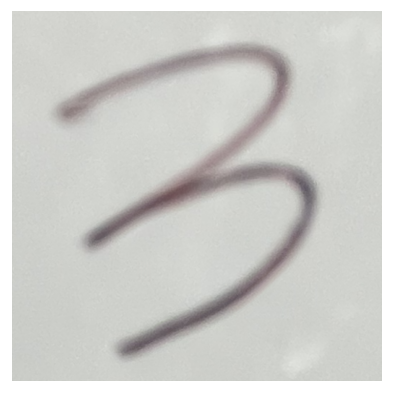

In [38]:
plt.imshow(X=test_img)
plt.axis('off')
plt.show()

## MNIST 크기로 변환

In [39]:
# 크기 확인
test_img.size

(512, 512)

In [ ]:
# MNIST와 동일한 크기로 변경
test_img = test_img.resize((28, 28))
test_img.size
# (28, 28)

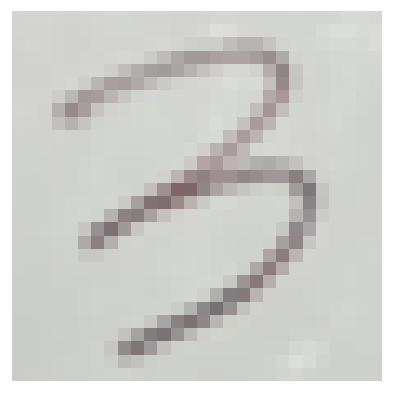

In [43]:
plt.imshow(X=test_img)
plt.axis('off')
plt.show()

## 흑백 이미지로 변환

In [44]:
# 색상모드 확인
test_img.mode
# 'RGBA'

'RGBA'

In [ ]:
# 흑백 이미지로 변환
test_img = test_img.convert(mode='L')

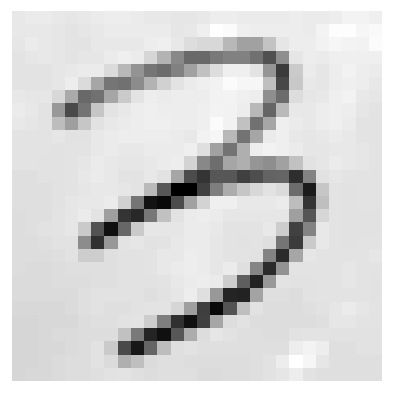

In [46]:
plt.imshow(X=test_img, cmap='grey')
plt.axis('off')
plt.show()

## 이미지 반전

In [47]:
# NumPy 배열로 변환
test_img = np.array(test_img)

In [ ]:
# 픽셀 값 반전하여 색 변환
test_img = np.invert(test_img)

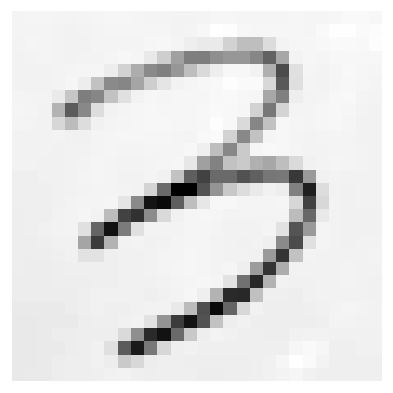

In [51]:
plt.imshow(X=test_img, cmap='grey')
plt.axis('off')
plt.show()

## 배경 잡음 제거

In [53]:
import cv2

In [54]:
threshold, _ = cv2.threshold(src=test_img, thresh=0, maxval=255, type=cv2.THRESH_BINARY + cv2.THRESH_OTSU)

In [55]:
test_img = np.where(test_img < threshold, 0, test_img)

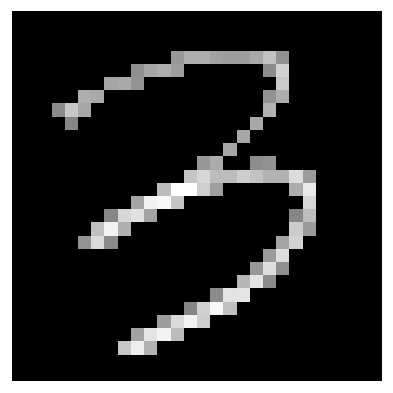

In [56]:
plt.imshow(X=test_img, cmap='grey')
plt.axis('off')
plt.show()

## 텐서로 변환

In [57]:
test_img = torch.tensor(test_img, dtype=torch.float32)

In [58]:
test_img = test_img.unsqueeze(dim=0)

In [59]:
test_img = test_img.flatten(1, -1)

In [ ]:
test_img.shape
# torch.Size([1, 784])

torch.Size([1, 784])

## 모델로 예측

In [ ]:
model.eval()
logits = model(test_img)
y_prob = torch.softmax(input=logits, dim=1)
y_pred = y_prob.argmax(dim=1)
print(y_pred)

## 함수로 생성

In [ ]:
def guess_digit(file):
    img = Image.open(fp=file, mode='r')
    img = img.resize((28, 28)).convert(mode='L')
    img = np.invert(np.array(img))
    thresh, _ = cv2.threshold(src=img, thresh=0, maxval=255, type=cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    img = np.where(img < thresh, 0, img)
    img = torch.tensor(img, dtype=torch.float32)
    img = img.unsqueeze(dim=0).flatten(1, -1)
    logits = model(img)
    y_pred = logits.argmax(dim=1)

    return y_pred